In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

link: https://colab.research.google.com/drive/1MSP9dSKdTg193p1UfnXxBqbI2bSpJwfg?usp=sharing

# LOAD & INSPECT DATASET

In [2]:
df = sns.load_dataset('tips') # Menggunakan dataset Tips
print(df.shape, '\n'*2, df.dtypes, '\n')
print(df.describe().round(2))

(244, 7) 

 total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object 

       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


# DASHBOARD

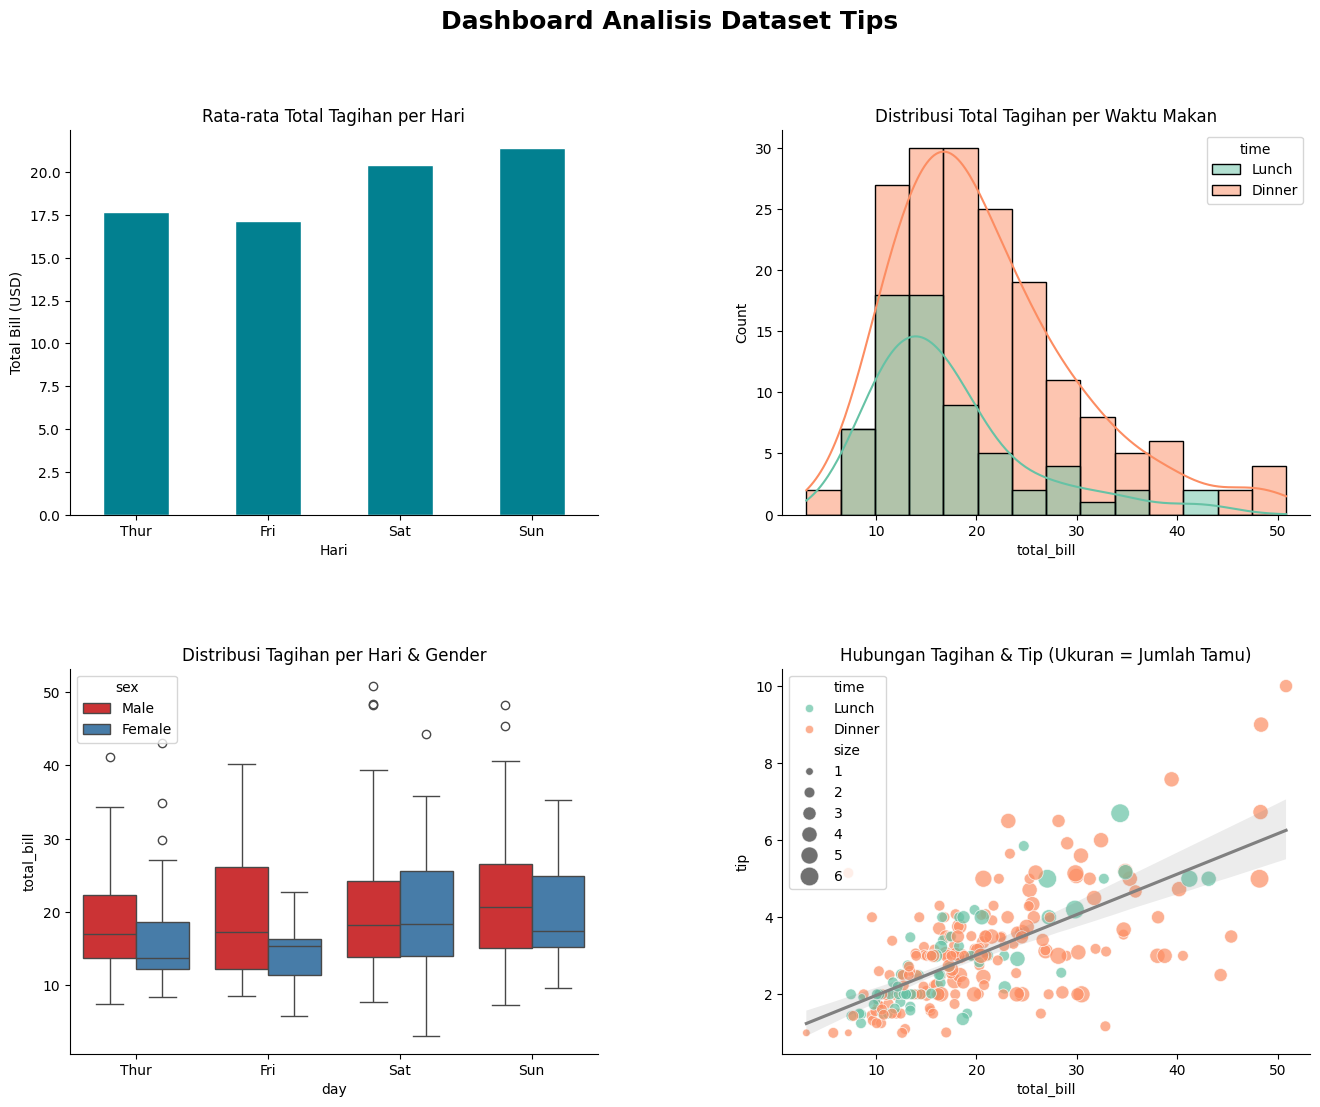

In [9]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
              fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

# GRAFIK 1: Bar Chart
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
                 edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# GRAFIK 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
             hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip',
                 hue='time', size='size', sizes=(30,180),
                 palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
             scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

## Rata-Rata Total Tagihan per Hari

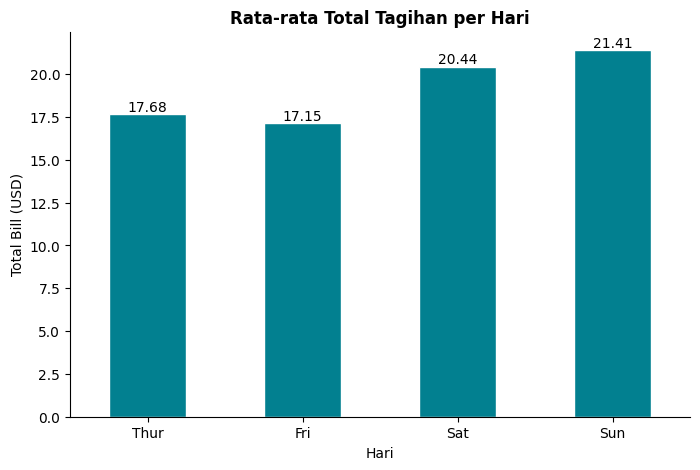

In [13]:
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()

plt.figure(figsize=(8, 5))
ax = avg_by_day.plot(kind='bar', color='#028090', edgecolor='white')

# Add labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.title('Rata-rata Total Tagihan per Hari', fontsize=12, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Total Bill (USD)')
plt.xticks(rotation=0)
sns.despine()

plt.show()

*   Hari Minggu mencatat rata-rata total tagihan tertinggi, yaitu di 21,41 USD, disusul oleh Hari Sabtu yang mencapai sekitar 20,44 USD.

*   Rata-rata tagihan pada hari kerja lebih rendah, di mana Hari Kamis  berada di 17,68 USD dan Hari Jumat merupakan yang terendah di angka sekitar 17,15 USD.

*   Pelanggan cenderung menghabiskan lebih banyak uang per transaksi pada akhir pekan (Sabtu & Minggu). Ini menunjukkan adanya perubahan perilaku konsumen kemungkinan besar karena akhir pekan digunakan untuk makan besar bersama keluarga atau kelompok besar, sementara hari kerja didominasi oleh makan siang kilat atau makan malam kasual yang lebih murah.

*   Tindak Lanjut Bisnis: Optimalkan pendapatan akhir pekan dengan strategi upselling (menawarkan menu premium atau paket keluarga).

## Distribusi Total Tagihan per Waktu Makan

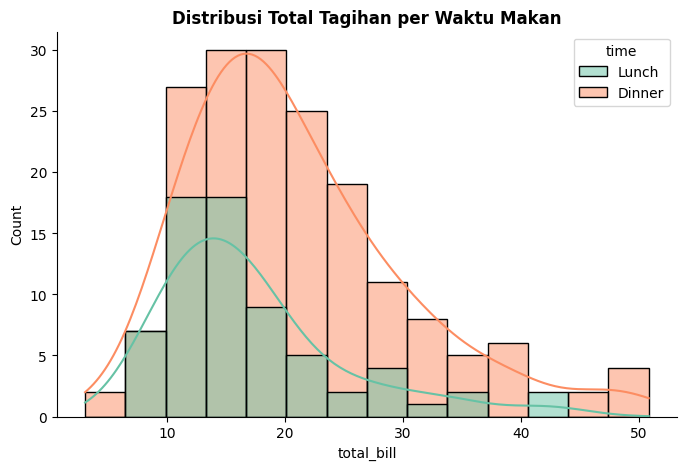

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2')

plt.title('Distribusi Total Tagihan per Waktu Makan', fontsize=12, fontweight='bold')
sns.despine()

plt.show()

*   Distribusi makan siang terpusat di area tagihan rendah, memuncak di kisaran 10 USD – 18 USD dengan jumlah frekuensi mencapai maksimal 18 kali kejadian. Jarang sekali ada tagihan makan siang yang melebihi 30 USD.

*   Distribusi makan malam jauh lebih luas (bergeser ke kanan) dan memiliki volume jauh lebih tinggi, memuncak di kisaran 15 USD – 20 USD (menyentuh 30 kali kejadian) dan terus memanjang hingga menyentuh angka ekstrem 50 USD.

*   Sesi makan malam adalah motor utama pendapatan restoran, baik dari sisi volume transaksi maupun nilai tagihan per transaksi. Makan siang memiliki potensi profit yang lebih terbatas dan pola pengeluaran konsumen yang lebih hemat.

*   Tindak Lanjut Bisnis: Alokasikan staf terbaik dan buat program promosi khusus (seperti wine pairing atau dessert promo) pada sesi makan malam untuk memaksimalkan revenue. Untuk makan siang, buat paket quick-lunch seharga 12 USD - 15 USD untuk menangkap volume pelanggan pekerja yang sensitif waktu dan harga.

## Distribusi Tagihan per Hari & Gender

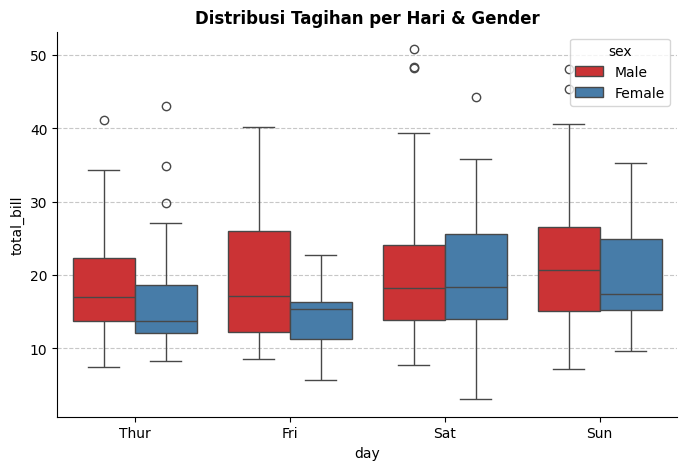

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1')

plt.title('Distribusi Tagihan per Hari & Gender', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

plt.show()

*   Pria: Secara konsisten memiliki nilai median tagihan yang lebih tinggi daripada wanita hampir di setiap hari, dengan median tertinggi di hari Minggu (di atas 20 USD). Pria juga menyumbang outliers tertinggi, terutama di hari Sabtu yang menyentuh angka lebih dari 50 USD.

*   Wanita: Memiliki pengeluaran yang lebih stabil dan lebih rendah. Namun, pada hari Sabtu, median pengeluaran wanita hampir menyamai median pengeluaran pria di hari yang sama. Ada outlier wanita yang cukup tinggi di hari Kamis dan Sabtu (di atas 40 USD).

*   Pelanggan pria cenderung memesan makanan/minuman dengan total biaya yang lebih mahal atau kemungkinan besar bertindak sebagai pembayar utama saat datang berkelompok. Hari Sabtu menjadi hari yang unik karena kesenjangan pengeluaran antara pria dan wanita paling menipis.

*   Tindak Lanjut Bisnis: Buat kampanye pemasaran yang ditargetkan untuk kelompok konsumen wanita di hari Sabtu (misalnya, "Ladies Night" atau promo grup wanita) untuk mendongkrak pengeluaran mereka agar melampaui hari-hari biasa.

## Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)

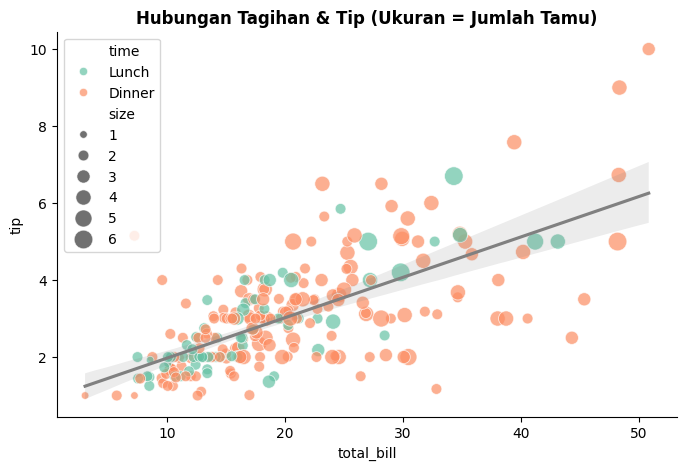

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30,180),
                palette='Set2', alpha=0.7)

sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray')

plt.title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=12, fontweight='bold')
sns.despine()

plt.show()

In [15]:
df[['total_bill','tip']].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


*   Terdapat korelasi positif yang kuat antara 'total_bill' dan 'tip'. Semakin besar tagihan, semakin besar tip yang diberikan.

*   Ukuran Ukuran Lingkaran (Size): Lingkaran besar (jumlah tamu 4-6 orang) mendominasi area kanan atas (tagihan > 30 USD dan tip > 5 USD). Tip tertinggi mencapai 10 USD diperoleh dari transaksi makan malam dengan tagihan sekitar 50 USD.

*   Mayoritas transaksi makan siang (hijau) menumpuk di area tagihan rendah dengan tip di bawah 4 USD.

*   Ukuran rombongan yang datang (size) berbanding lurus dengan jumlah tagihan, yang pada akhirnya secara otomatis meningkatkan pendapatan tip bagi pramusaji. Meja besar dengan kapasitas 4-6 orang adalah aset paling berharga bagi restoran dan kesejahteraan staf.

*   Tindak Lanjut Bisnis: Atur tata letak meja (table layout) agar dapat mengakomodasi lebih banyak rombongan besar (4-6 orang), terutama pada sesi makan malam di akhir pekan. Latih pramusaji untuk menangani kelompok besar dengan teknik hospitality ekstra karena potensi tip mereka sangat sensitif di area ini.

# EKSPOR

In [ ]:
fig.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

Dashboard tersimpan sebagai dashboard_tips.png
